# Q1: Ripple density — which brain area has the highest density of "hippocampal" ripples?

This notebook implements ripple detection on the CON2PHYS LFP data, aligned with:

1. **Buzsáki lab `detect_swr`** (buzcode: `detect_swr/detect_swr.m`) — ripple band 80–250 Hz, mean-subtract across channels before filtering, envelope + Gaussian smooth, **max across channels** at each time, **local** statistics (±Ns_chk window) for thresholding, min ripple duration 25 ms, min ISI 100 ms.
2. **Liu et al. (2022)** — Nature Communications consensus on detection and reporting.

**Key choices from detect_swr.m:** `ripBP = [80 250]`, `thresSDrip = [0.5 2.5]` (0.5 for duration boundary, 2.5 for peak), `minDurRP = 0.025` s, `minIsi = 0.10` s, `WinSize = 200` ms (non-overlapping windows for candidate peaks), `Ns_chk = 5` s (local baseline window). CON2PHYS provides a **single ordered chain per area** (channels deep → superficial, 20 µm spacing, spatially contiguous), so we use **sharp-wave–led detection** as in detect_swr: SW difference = superficial − deep (2–50 Hz), candidates = max SW in each window, then validate with both SW and ripple local thresholds and durations.

## Imports

In [8]:
import numpy as np
from pathlib import Path
from scipy.signal import butter, filtfilt, hilbert
from scipy.ndimage import gaussian_filter1d
from concurrent.futures import ProcessPoolExecutor
import os
import matplotlib.pyplot as plt

## Parameters

Detection parameters are set explicitly so that results can be reproduced and sensitivity can be tested (paper: "reported values can vary two orders of magnitude" with different choices).

In [9]:
dataset_folder = Path("./brainhack-dataset/")
fs = 500  # Hz (CON2PHYS LFP sampling rate)
n_mice = 18
lfp_files = ["lfp_1.npy", "lfp_2.npy", "lfp_3.npy"]  # one per brain area

# Sharp-wave and ripple — aligned with Buzsáki lab detect_swr.m defaults
sw_band = (2, 50)          # Hz; detect_swr: swBP = [2 50] (sharp wave)
ripple_band = (80, 250)    # Hz; detect_swr: ripBP = [80 250]
win_size_ms = 200          # ms; non-overlapping windows; candidate = time of max SW (WinSize)
ns_chk_sec = 5.0           # s; local baseline window ±Ns_chk
thres_sd_sw_high = 2.5     # SD for SW peak (thresSDswD(2))
thres_sd_sw_low = 0.5      # SD for SW duration boundary (thresSDswD(1))
thres_sd_rip_high = 2.5    # SD for ripple peak (thresSDrip(2))
thres_sd_rip_low = 0.5     # SD for ripple duration boundary (thresSDrip(1))
min_dur_sw_sec = 0.02      # s; min sharp-wave duration (minDurSW)
max_dur_sw_sec = 0.5       # s; max sharp-wave duration (maxDurSW)
min_dur_rip_sec = 0.025    # s; min ripple duration (minDurRP)
min_isi_sec = 0.10         # s; min interval between detections (minIsi)
rip_window_sec = np.pi / np.mean(ripple_band)  # Gaussian smooth ~6 ms

## Ripple detection helpers (detect_swr style)

1. **Mean-subtract** across channels (reduces common reference), then **bandpass** 80–250 Hz.
2. **Envelope** = abs(filtered), then **Gaussian smooth** (ripWindow ≈ 6 ms) so ripple power is smooth.
3. **Max across channels** at each time → one ripple-power trace per area.
4. **Sharp-wave difference:** Bandpass 2–50 Hz, then **superficial − deep** (CON2PHYS: row 0 = deep, last row = superficial). One SW trace per area.
5. **Candidates:** non-overlapping 200 ms windows; candidate time = time of **max sharp-wave** in window (SW-led, as in detect_swr).
6. **Validate each candidate:** local SW peak ≥ M+2.5*SD, local ripple (max in ±HalfWin around peak) ≥ M+2.5*SD; SW duration 20–500 ms; ripple duration ≥ 25 ms; min ISI 100 ms.

In [10]:
def bandpass(sig, low_hz, high_hz, fs, order=4):
    nyq = fs / 2
    low = max(low_hz / nyq, 0.01)
    high = min(high_hz / nyq, 0.99)
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, sig, axis=-1)


def compute_ripple_power_one_area(lfp, low_hz, high_hz, fs, rip_window_sec):
    """
    detect_swr style: mean-subtract across channels, bandpass, abs (envelope),
    Gaussian smooth, then max across channels. Returns 1D ripple power (n_samples,).
    """
    # lfp: (n_channels, n_samples)
    lfp = lfp.astype(float)
    lfp = lfp - np.mean(lfp, axis=0, keepdims=True)  # mean-subtract across channels
    filtered = bandpass(lfp, low_hz, high_hz, fs)
    envelope = np.abs(hilbert(filtered, axis=-1))
    # Gaussian smooth: sigma in samples so FWHM ~ rip_window_sec
    sigma_samp = rip_window_sec * fs / (2 * np.sqrt(2 * np.log(2)))  # ~ rip_window_sec * fs / 2.35
    sigma_samp = max(1.0, min(sigma_samp, 50))
    envelope_smooth = gaussian_filter1d(envelope, sigma=sigma_samp, axis=-1, mode="nearest")
    rip_power = np.max(envelope_smooth, axis=0)  # max across channels at each time
    return rip_power


def compute_sw_diff_one_area(lfp, low_hz, high_hz, fs):
    """
    Sharp-wave: bandpass 2–50 Hz, then superficial − deep.
    CON2PHYS: channels ordered deep → superficial (row 0 = deep, row -1 = superficial).
    Returns 1D sw_diff (n_samples,).
    """
    lfp = lfp.astype(float)
    filtered = bandpass(lfp, low_hz, high_hz, fs)  # (n_channels, n_samples)
    superficial = filtered[-1]   # last channel
    deep = filtered[0]           # first channel
    return superficial - deep


def get_candidate_peaks_sw_led(sw_diff, fs, win_size_ms):
    """Non-overlapping windows; return sample index of max sharp-wave in each window (SW-led)."""
    win_samp = int(win_size_ms * fs / 1000)
    n = len(sw_diff)
    candidates = []
    for start in range(0, n - win_samp, win_samp):
        chunk = sw_diff[start : start + win_samp]
        idx = np.argmax(chunk)
        candidates.append(start + idx)
    return np.array(candidates, dtype=int)


def validate_candidate_local(rip_power, peak_samp, fs, bound_samp, thres_low_sd, thres_high_sd, min_dur_samp):
    """
    Local stats in [peak_samp - bound_samp, peak_samp + bound_samp].
    Require rip_power[peak_samp] >= M + thres_high_sd*SD.
    Find start/stop where rip_power >= M + thres_low_sd*SD; require duration >= min_dur_samp.
    """
    s0 = max(0, peak_samp - bound_samp)
    s1 = min(len(rip_power), peak_samp + bound_samp + 1)
    seg = rip_power[s0:s1]
    M = np.median(seg)
    SD = np.std(seg)
    if SD <= 0:
        SD = 1.0
    peak_val = rip_power[peak_samp]
    if peak_val < M + thres_high_sd * SD:
        return False
    thresh = M + thres_low_sd * SD
    above = rip_power >= thresh
    # start: last sample before peak that is below thresh
    start = peak_samp
    while start > 0 and above[start - 1]:
        start -= 1
    # end: first sample after peak that is below thresh
    end = peak_samp
    while end < len(rip_power) - 1 and above[end + 1]:
        end += 1
    end += 1
    return (end - start) >= min_dur_samp


def _duration_above_thresh(sig, peak_samp, thresh):
    """Contiguous interval containing peak where sig >= thresh; return (start, end_exclusive)."""
    above = sig >= thresh
    start = peak_samp
    while start > 0 and above[start - 1]:
        start -= 1
    end = peak_samp
    while end < len(sig) - 1 and above[end + 1]:
        end += 1
    return start, end + 1


def validate_candidate_swr(
    sw_diff,
    rip_power,
    peak_samp,
    fs,
    bound_samp,
    half_win_samp,
    thres_sd_sw_low,
    thres_sd_sw_high,
    thres_sd_rip_low,
    thres_sd_rip_high,
    min_dur_sw_samp,
    max_dur_sw_samp,
    min_dur_rip_samp,
):
    """
    Full SW+ripple validation: local SW and ripple magnitude; SW duration in [min_dur_sw, max_dur_sw];
    ripple duration >= min_dur_rip. Ripple value at candidate = max(rip_power) in [peak - half_win, peak + half_win].
    """
    s0 = max(0, peak_samp - bound_samp)
    s1 = min(len(sw_diff), peak_samp + bound_samp + 1)
    # SW local stats
    sw_seg = sw_diff[s0:s1]
    M_sw = np.median(sw_seg)
    SD_sw = np.std(sw_seg)
    if SD_sw <= 0:
        SD_sw = 1.0
    if sw_diff[peak_samp] < M_sw + thres_sd_sw_high * SD_sw:
        return False
    sw_thresh = M_sw + thres_sd_sw_low * SD_sw
    start_sw, end_sw = _duration_above_thresh(sw_diff, peak_samp, sw_thresh)
    dur_sw = end_sw - start_sw
    if dur_sw < min_dur_sw_samp or dur_sw > max_dur_sw_samp:
        return False
    # Ripple: max in window around peak (like detect_swr)
    r0 = max(0, peak_samp - half_win_samp)
    r1 = min(len(rip_power), peak_samp + half_win_samp + 1)
    rip_at_peak = np.max(rip_power[r0:r1])
    rip_seg = rip_power[s0:s1]
    M_rip = np.median(rip_seg)
    SD_rip = np.std(rip_seg)
    if SD_rip <= 0:
        SD_rip = 1.0
    if rip_at_peak < M_rip + thres_sd_rip_high * SD_rip:
        return False
    rip_thresh = M_rip + thres_sd_rip_low * SD_rip
    start_rip, end_rip = _duration_above_thresh(rip_power, peak_samp, rip_thresh)
    if (end_rip - start_rip) < min_dur_rip_samp:
        return False
    return True


def count_ripples_detect_swr_style(
    sw_diff,
    rip_power,
    fs,
    win_size_ms,
    ns_chk_sec,
    thres_sd_sw_low,
    thres_sd_sw_high,
    thres_sd_rip_low,
    thres_sd_rip_high,
    min_dur_sw_sec,
    max_dur_sw_sec,
    min_dur_rip_sec,
    min_isi_sec,
):
    """
    SW-led detection: candidates = max SW in each window; validate with both SW and ripple.
    Returns (n_events, duration_sec).
    """
    bound_samp = int(ns_chk_sec * fs)
    half_win_samp = int((win_size_ms / 2) * fs / 1000)
    min_dur_sw_samp = int(min_dur_sw_sec * fs)
    max_dur_sw_samp = int(max_dur_sw_sec * fs)
    min_dur_rip_samp = int(min_dur_rip_sec * fs)
    min_isi_samp = int(min_isi_sec * fs)
    candidates = get_candidate_peaks_sw_led(sw_diff, fs, win_size_ms)
    valid_peaks = []
    for p in candidates:
        if p < bound_samp or p + bound_samp >= len(sw_diff):
            continue
        if validate_candidate_swr(
            sw_diff, rip_power, p, fs, bound_samp, half_win_samp,
            thres_sd_sw_low, thres_sd_sw_high,
            thres_sd_rip_low, thres_sd_rip_high,
            min_dur_sw_samp, max_dur_sw_samp, min_dur_rip_samp,
        ):
            valid_peaks.append(p)
    valid_peaks = np.sort(valid_peaks)
    kept = []
    last = -min_isi_samp - 1
    for p in valid_peaks:
        if p - last >= min_isi_samp:
            kept.append(p)
            last = p
    n_events = len(kept)
    duration_sec = len(rip_power) / fs
    return n_events, duration_sec

## Load LFP and compute SW difference + ripple power per area

Load `[n_channels, n_samples]` per area (channels deep → superficial). Compute **sw_diff** = superficial − deep (2–50 Hz) and **rip_power** (80–250 Hz, mean-subtract, envelope, smooth, max across channels).

In [11]:
def load_and_features_one_area(mouse_id, area_idx, dataset_folder, lfp_files, fs, sw_band, ripple_band, rip_window_sec):
    """Load one area LFP; return (sw_diff, rip_power) both 1D. Channels: deep→superficial."""
    path = dataset_folder / str(mouse_id) / lfp_files[area_idx]
    lfp = np.load(path)  # (n_channels, n_samples)
    sw_diff = compute_sw_diff_one_area(lfp, sw_band[0], sw_band[1], fs)
    rip_power = compute_ripple_power_one_area(lfp, ripple_band[0], ripple_band[1], fs, rip_window_sec)
    return sw_diff, rip_power

## Detection summary

**SW-led:** Candidates = time of max sharp-wave (2–50 Hz, superficial−deep) in each 200 ms window. For each candidate, ripple power = max in ±100 ms. Validate with **local** ±5 s stats: SW peak ≥ 2.5 SD, ripple ≥ 2.5 SD; SW duration 20–500 ms; ripple duration ≥ 25 ms; min ISI 100 ms.

In [12]:
# Counting uses count_ripples_detect_swr_style(sw_diff, rip_power, ...) with SW-led candidates.

## Run detection for all mice and all areas

Compute ripple count and recording duration per (mouse, area); then density = count / duration (e.g. events per minute).

In [13]:
def _process_one_mouse_area(args):
    """Worker: run load + detection for one (mouse_id, area_idx). Receives all params for portability."""
    (mouse_id, area_idx), p = args
    from pathlib import Path
    dataset_folder = Path(p["dataset_folder"])
    try:
        sw_diff, rip_power = load_and_features_one_area(
            mouse_id, area_idx, dataset_folder, p["lfp_files"], p["fs"],
            p["sw_band"], p["ripple_band"], p["rip_window_sec"],
        )
        n_rip, dur = count_ripples_detect_swr_style(
            sw_diff, rip_power, p["fs"],
            p["win_size_ms"], p["ns_chk_sec"],
            p["thres_sd_sw_low"], p["thres_sd_sw_high"],
            p["thres_sd_rip_low"], p["thres_sd_rip_high"],
            p["min_dur_sw_sec"], p["max_dur_sw_sec"], p["min_dur_rip_sec"], p["min_isi_sec"],
        )
        return (mouse_id, area_idx + 1, n_rip, dur)
    except Exception as e:
        return (mouse_id, area_idx + 1, None, None, str(e))


# Bundle params so workers don't rely on notebook globals (needed for spawn/fork)
_params = {
    "dataset_folder": str(dataset_folder.resolve()),
    "lfp_files": lfp_files,
    "fs": fs,
    "sw_band": sw_band,
    "ripple_band": ripple_band,
    "rip_window_sec": float(rip_window_sec),
    "win_size_ms": win_size_ms,
    "ns_chk_sec": ns_chk_sec,
    "thres_sd_sw_low": thres_sd_sw_low,
    "thres_sd_sw_high": thres_sd_sw_high,
    "thres_sd_rip_low": thres_sd_rip_low,
    "thres_sd_rip_high": thres_sd_rip_high,
    "min_dur_sw_sec": min_dur_sw_sec,
    "max_dur_sw_sec": max_dur_sw_sec,
    "min_dur_rip_sec": min_dur_rip_sec,
    "min_isi_sec": min_isi_sec,
}
_tasks = [((mid, aid), _params) for mid in range(1, n_mice + 1) for aid in range(3)]
_n_workers = min(len(_tasks), os.cpu_count() or 8)

# Run in parallel; worker needs access to helpers (same notebook kernel)
with ProcessPoolExecutor(max_workers=_n_workers) as executor:
    _raw = list(executor.map(_process_one_mouse_area, _tasks))

results = []
for r in _raw:
    if len(r) == 5:
        mouse_id, area, n_rip, dur, err = r
        if n_rip is not None:
            results.append((mouse_id, area, n_rip, dur))
        else:
            print(f"Mouse {mouse_id} area {area}: {err}")
    else:
        # success: (mouse_id, area, n_rip, dur)
        results.append(r)
print(f"Processed {len(results)} mouse-area pairs (max_workers={_n_workers}).")

Processed 54 mouse-area pairs (max_workers=54).


## Aggregate density per area and answer Q1

In [14]:
# Sum counts and durations per area across mice
area_counts = {1: 0, 2: 0, 3: 0}
area_durations = {1: 0.0, 2: 0.0, 3: 0.0}

for mouse_id, area, n_rip, dur in results:
    area_counts[area] += n_rip
    area_durations[area] += dur

densities = {}
for area in [1, 2, 3]:
    d = area_durations[area]
    densities[area] = (area_counts[area] / (d / 60.0)) if d > 0 else 0  # events per minute

print("Ripple density (events per minute) by brain area:")
for area in [1, 2, 3]:
    print(f"  Area {area}: {densities[area]:.2f} (n = {area_counts[area]} events, {area_durations[area]/60:.1f} min)")

best_area = max(densities, key=densities.get)
print(f"\n** Q1 answer: Brain area {best_area} has the highest ripple density ({densities[best_area]:.2f} events/min). **")

Ripple density (events per minute) by brain area:
  Area 1: 9.39 (n = 12264 events, 1305.4 min)
  Area 2: 6.53 (n = 8518 events, 1305.4 min)
  Area 3: 8.83 (n = 11533 events, 1305.4 min)

** Q1 answer: Brain area 1 has the highest ripple density (9.39 events/min). **


## Bar plots per mouse

Create a directory and save one PNG per mouse (ripple density by brain area).

In [ ]:
out_dir = Path("figures/ripple_by_mouse")
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving per-mouse bar plots to {out_dir.resolve()}")

for mouse_id in range(1, n_mice + 1):
    mouse_results = [(area, n_rip, dur) for (mid, area, n_rip, dur) in results if mid == mouse_id]
    if len(mouse_results) < 3:
        print(f"Mouse {mouse_id}: only {len(mouse_results)} areas, skipping")
        continue
    area_to_density = {}
    for area, n_rip, dur in mouse_results:
        area_to_density[area] = (n_rip / (dur / 60.0)) if dur > 0 else 0.0
    areas = sorted(area_to_density.keys())
    densities = [area_to_density[a] for a in areas]
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    ax.bar(areas, densities, color="steelblue", edgecolor="k")
    ax.set_xlabel("Brain area")
    ax.set_ylabel("Ripple density (events/min)")
    ax.set_title(f"Mouse {mouse_id}: ripple density by area")
    plt.tight_layout()
    fig.savefig(out_dir / f"mouse_{mouse_id:02d}.png", bbox_inches="tight")
    plt.close(fig)

print(f"Saved {n_mice} PNGs to {out_dir}")

## Optional: Bar plot of densities

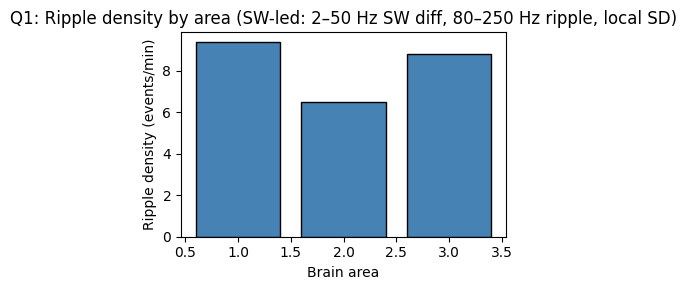

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(list(densities.keys()), list(densities.values()), color="steelblue", edgecolor="k")
ax.set_xlabel("Brain area")
ax.set_ylabel("Ripple density (events/min)")
ax.set_title("Q1: Ripple density by area (SW-led: 2–50 Hz SW diff, 80–250 Hz ripple, local SD)")
plt.tight_layout()
plt.show()